In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from model import (
    simulate_monod, residuals_monod,
    simulate_haldane, residuals_haldane,
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

# Load the same dataset used in 02_monod_fit
df = pd.read_csv('../data/synthetic_batch_fermentation.csv')
t_data = df['time_h'].values
X_data = df['biomass_gL'].values
S_data = df['substrate_gL'].values
X0, S0 = X_data[0], S_data[0]

print(f"Loaded {len(df)} data points. X0={X0:.3f}, S0={S0:.3f}")

Loaded 31 data points. X0=0.051, S0=10.926


In [4]:
# Haldane has 4 parameters: [mu_max, Ks, Ki, Yxs]
# Initial guesses: same as Monod, plus a "weak inhibition" Ki guess
p0_haldane = [0.5, 0.5, 50.0, 0.4]
lower_bounds = [0.01, 0.001, 0.1, 0.1]
upper_bounds = [2.0, 10.0, 1000.0, 1.0]

result_haldane = least_squares(
    residuals_haldane,
    x0=p0_haldane,
    bounds=(lower_bounds, upper_bounds),
    args=(t_data, X_data, S_data, X0, S0),
    method='trf',
    verbose=2,
)

mu_max_h, Ks_h, Ki_h, Yxs_h = result_haldane.x
print(f"\nHaldane fitted parameters:")
print(f"  mu_max = {mu_max_h:.4f} 1/h")
print(f"  Ks     = {Ks_h:.4f} g/L")
print(f"  Ki     = {Ki_h:.4f} g/L")
print(f"  Yxs    = {Yxs_h:.4f} g/g")
print(f"\nFit success: {result_haldane.success}")
print(f"Final cost: {result_haldane.cost:.6f}")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.8679e-01                                    1.92e+01    
       1              2         8.7906e-02      2.99e-01       2.24e+01       5.67e+00    
       2              3         6.5287e-02      2.26e-02       1.76e+01       1.37e+00    
       3              5         6.3344e-02      1.94e-03       9.86e+00       2.51e-01    
       4              6         6.2434e-02      9.10e-04       1.85e+01       5.44e-01    
       5              8         6.1998e-02      4.36e-04       9.81e+00       9.65e-02    
       6              9         6.1833e-02      1.65e-04       1.97e+01       2.88e-01    
       7             10         6.1686e-02      1.46e-04       1.96e+01       1.78e-01    
       8             11         6.1686e-02      7.47e-07       3.87e+01       4.62e-01    
       9             12         6.1495e-02      1.90e-04       9.46e+00       3.31e-03    

In [5]:
# Re-fit Monod in this notebook so both result objects are in the same kernel
# (needed for AIC comparison and visualization)
p0_monod = [0.4, 0.1, 0.5]
lower_bounds_m = [0.01, 0.001, 0.1]
upper_bounds_m = [2.0, 10.0, 1.0]

result_monod = least_squares(
    residuals_monod,
    x0=p0_monod,
    bounds=(lower_bounds_m, upper_bounds_m),
    args=(t_data, X_data, S_data, X0, S0),
    method='trf',
    verbose=0,
)

mu_max_m, Ks_m, Yxs_m = result_monod.x
print(f"Monod re-fitted parameters (this notebook):")
print(f"  mu_max = {mu_max_m:.4f} 1/h")
print(f"  Ks     = {Ks_m:.4f} g/L")
print(f"  Yxs    = {Yxs_m:.4f} g/g")
print(f"Cost: {result_monod.cost:.6f}")

Monod re-fitted parameters (this notebook):
  mu_max = 0.4802 1/h
  Ks     = 0.7244 g/L
  Yxs    = 0.4441 g/g
Cost: 0.060898


In [6]:
def aic_from_residuals(residuals, n_params, n_data):
    """
    Akaike Information Criterion under Gaussian noise assumption.

    AIC = n * log(SSR / n) + 2 * k
    where n = number of data points, k = number of parameters, SSR = sum of squared residuals.

    Lower AIC = better model (parsimony-corrected fit quality).
    """
    ssr = np.sum(residuals ** 2)
    n = n_data
    k = n_params
    return n * np.log(ssr / n) + 2 * k


# Get residuals (post-fit) for each model
res_monod = residuals_monod(result_monod.x, t_data, X_data, S_data, X0, S0)
res_haldane = residuals_haldane(result_haldane.x, t_data, X_data, S_data, X0, S0)

# Total data points = 2 * len(t_data) because we fit both biomass and substrate
n_data = 2 * len(t_data)

aic_monod = aic_from_residuals(res_monod, n_params=3, n_data=n_data)
aic_haldane = aic_from_residuals(res_haldane, n_params=4, n_data=n_data)

delta_aic = aic_haldane - aic_monod

print(f"AIC (Monod, 3 params):   {aic_monod:.2f}")
print(f"AIC (Haldane, 4 params): {aic_haldane:.2f}")
print(f"Delta AIC (Haldane - Monod): {delta_aic:+.2f}")
print()

if delta_aic > 2:
    print("Monod is favored (Haldane's extra parameter not justified by improved fit).")
elif delta_aic < -2:
    print("Haldane is favored (substrate inhibition adds real explanatory power).")
else:
    print("Models are statistically indistinguishable (|Delta AIC| < 2).")

AIC (Monod, 3 params):   -380.42
AIC (Haldane, 4 params): -378.28
Delta AIC (Haldane - Monod): +2.13

Monod is favored (Haldane's extra parameter not justified by improved fit).


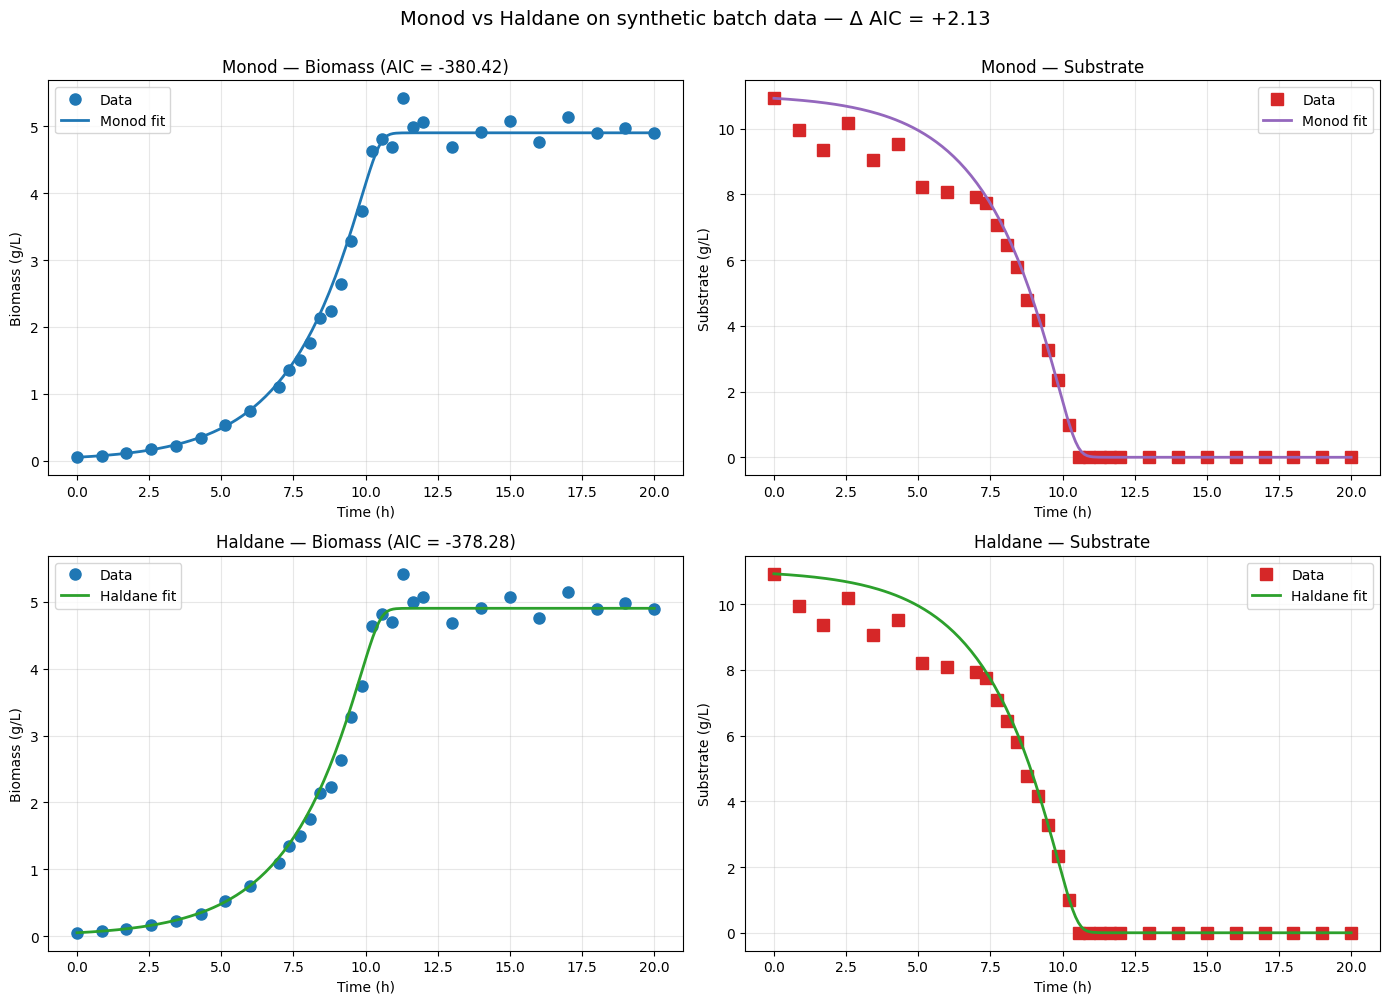

In [8]:
# Forward-simulate both models on a fine time grid
t_smooth = np.linspace(t_data.min(), t_data.max(), 200)
X_monod, S_monod = simulate_monod(result_monod.x, t_smooth, X0, S0)
X_haldane, S_haldane = simulate_haldane(result_haldane.x, t_smooth, X0, S0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row: Monod
axes[0,0].plot(t_data, X_data, 'o', color='C0', label='Data', markersize=8)
axes[0,0].plot(t_smooth, X_monod, '-', color='C0', label='Monod fit', linewidth=2)
axes[0,0].set_xlabel('Time (h)'); axes[0,0].set_ylabel('Biomass (g/L)')
axes[0,0].set_title(f'Monod — Biomass (AIC = {aic_monod:.2f})')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(t_data, S_data, 's', color='C3', label='Data', markersize=8)
axes[0,1].plot(t_smooth, S_monod, '-', color='C4', label='Monod fit', linewidth=2)
axes[0,1].set_xlabel('Time (h)'); axes[0,1].set_ylabel('Substrate (g/L)')
axes[0,1].set_title('Monod — Substrate')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Bottom row: Haldane
axes[1,0].plot(t_data, X_data, 'o', color='C0', label='Data', markersize=8)
axes[1,0].plot(t_smooth, X_haldane, '-', color='C2', label='Haldane fit', linewidth=2)
axes[1,0].set_xlabel('Time (h)'); axes[1,0].set_ylabel('Biomass (g/L)')
axes[1,0].set_title(f'Haldane — Biomass (AIC = {aic_haldane:.2f})')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(t_data, S_data, 's', color='C3', label='Data', markersize=8)
axes[1,1].plot(t_smooth, S_haldane, '-', color='C2', label='Haldane fit', linewidth=2)
axes[1,1].set_xlabel('Time (h)'); axes[1,1].set_ylabel('Substrate (g/L)')
axes[1,1].set_title('Haldane — Substrate')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.suptitle(f'Monod vs Haldane on synthetic batch data — Δ AIC = {delta_aic:+.2f}', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('../figures/04_monod_vs_haldane.png', bbox_inches='tight')
plt.show()